# Face Emotion Detection - AffectNet

## 1. Install Libraries

Run this cell once per environment if the packages are not available.

In [1]:
!pip install -q kagglehub tensorflow opencv-python scikit-learn matplotlib pandas pillow

## 2. Imports and Project Paths

In [2]:
import json
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

try:
    import kagglehub
except ImportError:
    kagglehub = None

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').exists() else NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
MODEL_DIR = ARTIFACTS_DIR / 'models'
OUTPUT_DIR = ARTIFACTS_DIR / 'outputs'
UPLOAD_DIR = OUTPUT_DIR / 'uploaded_images'

for path in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, OUTPUT_DIR, UPLOAD_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))
print('Project root:', PROJECT_ROOT)
print('Raw data dir:', RAW_DIR)
print('Model dir:', MODEL_DIR)

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project root: /
Raw data dir: /data/raw
Model dir: /artifacts/models


In [ ]:
# Demo helper functions for visualization

# def show_image_grid(image_paths, titles=None, cols=4, figsize_per_img=3):
#     image_paths = list(image_paths)
#     if not image_paths:
#         print("No images to display.")
#         return

#     rows = int(np.ceil(len(image_paths) / cols))
#     fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_img, rows * figsize_per_img))
#     axes = np.array(axes).reshape(rows, cols)

#     for idx, ax in enumerate(axes.flat):
#         ax.axis("off")
#         if idx >= len(image_paths):
#             continue

#         image_path = Path(image_paths[idx])
#         try:
#             image = Image.open(image_path).convert("RGB")
#             ax.imshow(image)
#             if titles is not None:
#                 ax.set_title(str(titles[idx]), fontsize=10)
#         except Exception as exc:
#             ax.text(0.5, 0.5, f"Cannot read\n{image_path.name}", ha="center", va="center")

#     plt.tight_layout()
#     plt.show()

## 3. Configuration

If  AffectNet have extracted locally, point `LOCAL_DATASET_ROOTS` to that folder. If `data/raw` already contains dataset folders, the notebook will use them automatically and skip downloading.

In [4]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 8
EPOCHS_FINE_TUNE = 8
VALID_SIZE = 0.15
TEST_SIZE = 0.15
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 1e-5
USE_MIXED_PRECISION = True
COPY_DATASETS_TO_RAW = False

KAGGLE_DATASETS = ['mstjebashazida/affectnet']
LOCAL_DATASET_ROOTS = []

CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

AFFECTNET_ID_TO_LABEL = {
    0: 'neutral',
    1: 'happy',
    2: 'sad',
    3: 'surprise',
    4: 'fear',
    5: 'disgust',
    6: 'angry',
    7: None,
    8: None,
    9: None,
    10: None,
}

LABEL_ALIASES = {
    'angry': 'angry', 'anger': 'angry', 'angriness': 'angry',
    'disgust': 'disgust', 'disgusted': 'disgust',
    'fear': 'fear', 'fearful': 'fear',
    'happy': 'happy', 'happiness': 'happy',
    'neutral': 'neutral',
    'sad': 'sad', 'sadness': 'sad',
    'surprise': 'surprise', 'surprised': 'surprise',
}

AFFECTNET_LABEL_COLUMNS = [
    'expression', 'exp', 'emotion', 'label', 'class', 'category', 'emotion_label', 'expression_label'
]
AFFECTNET_PATH_COLUMNS = [
    'subDirectory_filePath', 'subdirectory_filepath', 'filepath', 'file_path', 'path', 'image', 'image_path', 'filename', 'file'
]

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if USE_MIXED_PRECISION and tf.config.list_physical_devices('GPU'):
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision enabled.')
else:
    print('Mixed precision disabled.')

Mixed precision enabled.


## 4. Locate or Download Dataset

In [5]:
def is_colab_runtime():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False


def is_kaggle_runtime():
    return Path('/kaggle/input').exists()


def find_kaggle_input_roots():
    input_dir = Path('/kaggle/input')
    if not input_dir.exists():
        return []
    return [p.resolve() for p in input_dir.iterdir() if p.is_dir()]


def find_local_raw_roots(raw_dir):
    if not raw_dir.exists():
        return []
    roots = [p.resolve() for p in raw_dir.iterdir() if p.is_dir()]
    return roots


def prepare_kaggle_credentials():
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_json = kaggle_dir / 'kaggle.json'
    if kaggle_json.exists() or os.environ.get('KAGGLE_USERNAME'):
        return

    if is_kaggle_runtime():
        print('Kaggle runtime detected. Prefer adding the dataset as an Input.')
        return

    if is_colab_runtime():
        print('Upload kaggle.json from your Kaggle account settings.')
        from google.colab import files  # type: ignore
        uploaded = files.upload()
        if 'kaggle.json' not in uploaded:
            raise FileNotFoundError('kaggle.json was not uploaded.')
        kaggle_dir.mkdir(parents=True, exist_ok=True)
        kaggle_json.write_bytes(uploaded['kaggle.json'])
        try:
            os.chmod(kaggle_json, 0o600)
        except OSError:
            pass
        return

    raise FileNotFoundError(
        'No Kaggle credentials found. Put kaggle.json in ~/.kaggle or set KAGGLE_USERNAME/KAGGLE_KEY.'
    )


def download_kaggle_datasets(dataset_slugs, raw_dir, copy_to_raw=False):
    if LOCAL_DATASET_ROOTS:
        roots = [Path(p).expanduser().resolve() for p in LOCAL_DATASET_ROOTS]
        missing = [str(p) for p in roots if not p.exists()]
        if missing:
            raise FileNotFoundError('LOCAL_DATASET_ROOTS not found: ' + ', '.join(missing))
        print('Using LOCAL_DATASET_ROOTS:', roots)
        return roots

    local_roots = find_local_raw_roots(raw_dir)
    if local_roots:
        print('Using dataset folders already present in data/raw:', local_roots)
        return local_roots

    kaggle_input_roots = find_kaggle_input_roots()
    if kaggle_input_roots:
        print('Using Kaggle Input roots:', kaggle_input_roots)
        return kaggle_input_roots

    if kagglehub is None:
        raise ImportError('kagglehub is not installed. Run the install cell first.')

    prepare_kaggle_credentials()

    downloaded_paths = []
    for slug in dataset_slugs:
        print(f'Downloading or locating Kaggle dataset: {slug}')
        dataset_path = Path(kagglehub.dataset_download(slug)).resolve()
        if copy_to_raw:
            target_path = raw_dir / slug.replace('/', '__')
            if target_path.exists():
                print('Target already exists, reusing:', target_path)
            else:
                import shutil
                shutil.copytree(dataset_path, target_path)
            dataset_path = target_path.resolve()
        downloaded_paths.append(dataset_path)
        print('Dataset root:', dataset_path)

    return downloaded_paths


dataset_roots = download_kaggle_datasets(
    KAGGLE_DATASETS,
    RAW_DIR,
    copy_to_raw=COPY_DATASETS_TO_RAW,
)
dataset_roots

Kaggle runtime detected. Prefer adding the dataset as an Input.
Using Colab cache for faster access to the 'affectnet' dataset.
Dataset root: /kaggle/input/affectnet


[PosixPath('/kaggle/input/affectnet')]

## 5. Normalize Labels and Build the Index

In [6]:
def normalize_label(value, numeric_mapping='affectnet'):
    if pd.isna(value):
        return None

    text = str(value).strip().lower().replace(' ', '_')
    if text in {'', 'nan', 'none', 'uncertain', 'non_face', 'non-face', 'contempt'}:
        return None

    try:
        numeric = int(float(text))
        if numeric_mapping == 'affectnet':
            return AFFECTNET_ID_TO_LABEL.get(numeric)
    except ValueError:
        pass

    return LABEL_ALIASES.get(text)


def infer_label_from_path(path):
    parts = [p.lower().replace(' ', '_') for p in Path(path).parts]
    for part in reversed(parts):
        label = normalize_label(part, numeric_mapping='affectnet')
        if label is not None:
            return label
    return None


def first_matching_column(columns, candidates):
    normalized = {str(col).strip().lower(): col for col in columns}
    for candidate in candidates:
        if candidate.lower() in normalized:
            return normalized[candidate.lower()]
    return None


def find_existing_image(root, value):
    candidate = Path(str(value).strip())
    candidates = []
    if candidate.is_absolute():
        candidates.append(candidate)
    else:
        clean_value = str(value).strip().lstrip('/\\')
        candidates.extend([
            Path(root) / candidate,
            Path(root) / clean_value,
            Path(root) / 'Manually_Annotated' / 'Manually_Annotated_Images' / clean_value,
            Path(root) / 'Automatically_Annotated' / 'Automatically_Annotated_Images' / clean_value,
        ])

    for item in candidates:
        if item.exists() and item.suffix.lower() in IMAGE_EXTS:
            return item.resolve()
    return None


def collect_affectnet_csv_records(root):
    records = []
    for csv_path in Path(root).rglob('*.csv'):
        try:
            sample = pd.read_csv(csv_path, nrows=5)
        except Exception:
            continue

        path_col = first_matching_column(sample.columns, AFFECTNET_PATH_COLUMNS)
        label_col = first_matching_column(sample.columns, AFFECTNET_LABEL_COLUMNS)
        if path_col is None or label_col is None:
            continue

        print('Reading AffectNet annotations:', csv_path)
        for chunk in pd.read_csv(csv_path, usecols=[path_col, label_col], chunksize=50000):
            chunk = chunk.dropna(subset=[path_col, label_col])
            for row in chunk.itertuples(index=False):
                image_value, label_value = row
                label = normalize_label(label_value, numeric_mapping='affectnet')
                if label is None:
                    continue
                image_path = find_existing_image(root, image_value)
                if image_path is None:
                    continue
                records.append({
                    'path': str(image_path),
                    'label': label,
                    'source': Path(root).name,
                    'annotation_file': csv_path.name,
                })
    return records


def collect_folder_label_records(root):
    records = []
    for file_path in Path(root).rglob('*'):
        if file_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label = infer_label_from_path(file_path.relative_to(root))
        if label is not None:
            records.append({
                'path': str(file_path.resolve()),
                'label': label,
                'source': Path(root).name,
                'annotation_file': None,
            })
    return records


def collect_image_files(dataset_roots):
    records = []
    for root in dataset_roots:
        root = Path(root)
        csv_records = collect_affectnet_csv_records(root)
        if csv_records:
            records.extend(csv_records)
        else:
            records.extend(collect_folder_label_records(root))

    df_images = pd.DataFrame(records)
    if df_images.empty:
        return pd.DataFrame(columns=['path', 'label', 'source', 'annotation_file'])

    df_images = df_images.drop_duplicates('path').reset_index(drop=True)
    df_images = df_images[df_images['label'].isin(CLASS_NAMES)].copy()
    df_images['label_id'] = df_images['label'].map(CLASS_TO_ID)
    return df_images


df_images = collect_image_files(dataset_roots)
print('Images found:', len(df_images))
display(df_images['label'].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int))

label_index_demo = pd.DataFrame({
    'example_path': [
        'Train/happiness/image_001.jpg',
        'Train/anger/image_002.jpg',
        'Train/surprised/image_003.jpg',
        'Train/contempt/image_004.jpg',
        'Train/non_face/image_005.jpg',
    ],
    'raw_label': ['happiness', 'anger', 'surprised', 'contempt', 'non_face'],
})
label_index_demo['normalized_label'] = label_index_demo['raw_label'].map(normalize_label)
label_index_demo['label_id'] = label_index_demo['normalized_label'].map(CLASS_TO_ID)
label_index_demo['index_status'] = np.where(
    label_index_demo['normalized_label'].notna(),
    'kept in 7-class index',
    'removed before training',
)
display(label_index_demo)

df_images.head()

Images found: 27755


,count
label,
angry,3218
disgust,2477
fear,3176
happy,5044
neutral,5126
sad,4675
surprise,4039


,example_path,raw_label,normalized_label,label_id,index_status
0,Train/happiness/image_001.jpg,happiness,happy,3.0,kept in 7-class index
1,Train/anger/image_002.jpg,anger,angry,0.0,kept in 7-class index
2,Train/surprised/image_003.jpg,surprised,surprise,6.0,kept in 7-class index
3,Train/contempt/image_004.jpg,contempt,None,NaN,removed before training
4,Train/non_face/image_005.jpg,non_face,None,NaN,removed before training


,path,label,source,annotation_file,label_id
0,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
1,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
2,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
3,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
4,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6


## 5.1 Data Preview

Run these cells before training to inspect the dataset that was found.

In [7]:
print('Total images:', len(df_images))
print('Unique sources:', df_images['source'].nunique() if not df_images.empty else 0)
print('Missing files:', 0 if df_images.empty else int((~df_images['path'].map(lambda p: Path(p).exists())).sum()))

display(df_images.head(10))

overview = pd.DataFrame({
    'count': df_images['label'].value_counts(),
    'percent': (df_images['label'].value_counts(normalize=True) * 100).round(2),
}).reindex(CLASS_NAMES).fillna(0)
display(overview)

Total images: 27755
Unique sources: 1
Missing files: 0


,path,label,source,annotation_file,label_id
0,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
1,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
2,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
3,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
4,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
5,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
6,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
7,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
8,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6
9,/kaggle/input/affectnet/archive (3)/Test/surpr...,surprise,affectnet,None,6


,count,percent
label,,
angry,3218,11.59
disgust,2477,8.92
fear,3176,11.44
happy,5044,18.17
neutral,5126,18.47
sad,4675,16.84
surprise,4039,14.55


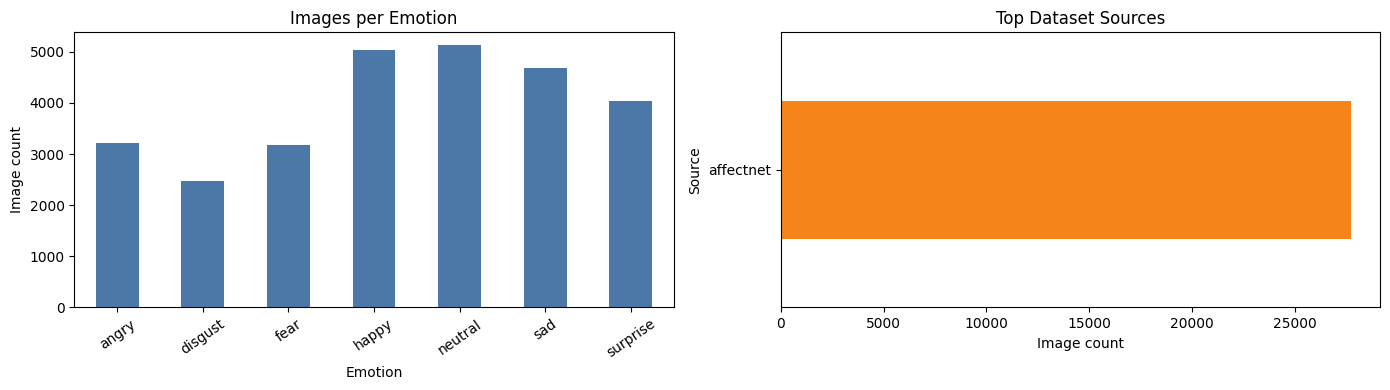

In [8]:
if df_images.empty:
    print('No images to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    label_counts = df_images['label'].value_counts().reindex(CLASS_NAMES).fillna(0)
    label_counts.plot(kind='bar', ax=axes[0], color='#4C78A8')
    axes[0].set_title('Images per Emotion')
    axes[0].set_xlabel('Emotion')
    axes[0].set_ylabel('Image count')
    axes[0].tick_params(axis='x', rotation=35)

    source_counts = df_images['source'].value_counts().head(10)
    source_counts.plot(kind='barh', ax=axes[1], color='#F58518')
    axes[1].set_title('Top Dataset Sources')
    axes[1].set_xlabel('Image count')
    axes[1].set_ylabel('Source')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1571/1104936809.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), samples_per_class), random_state=SEED))


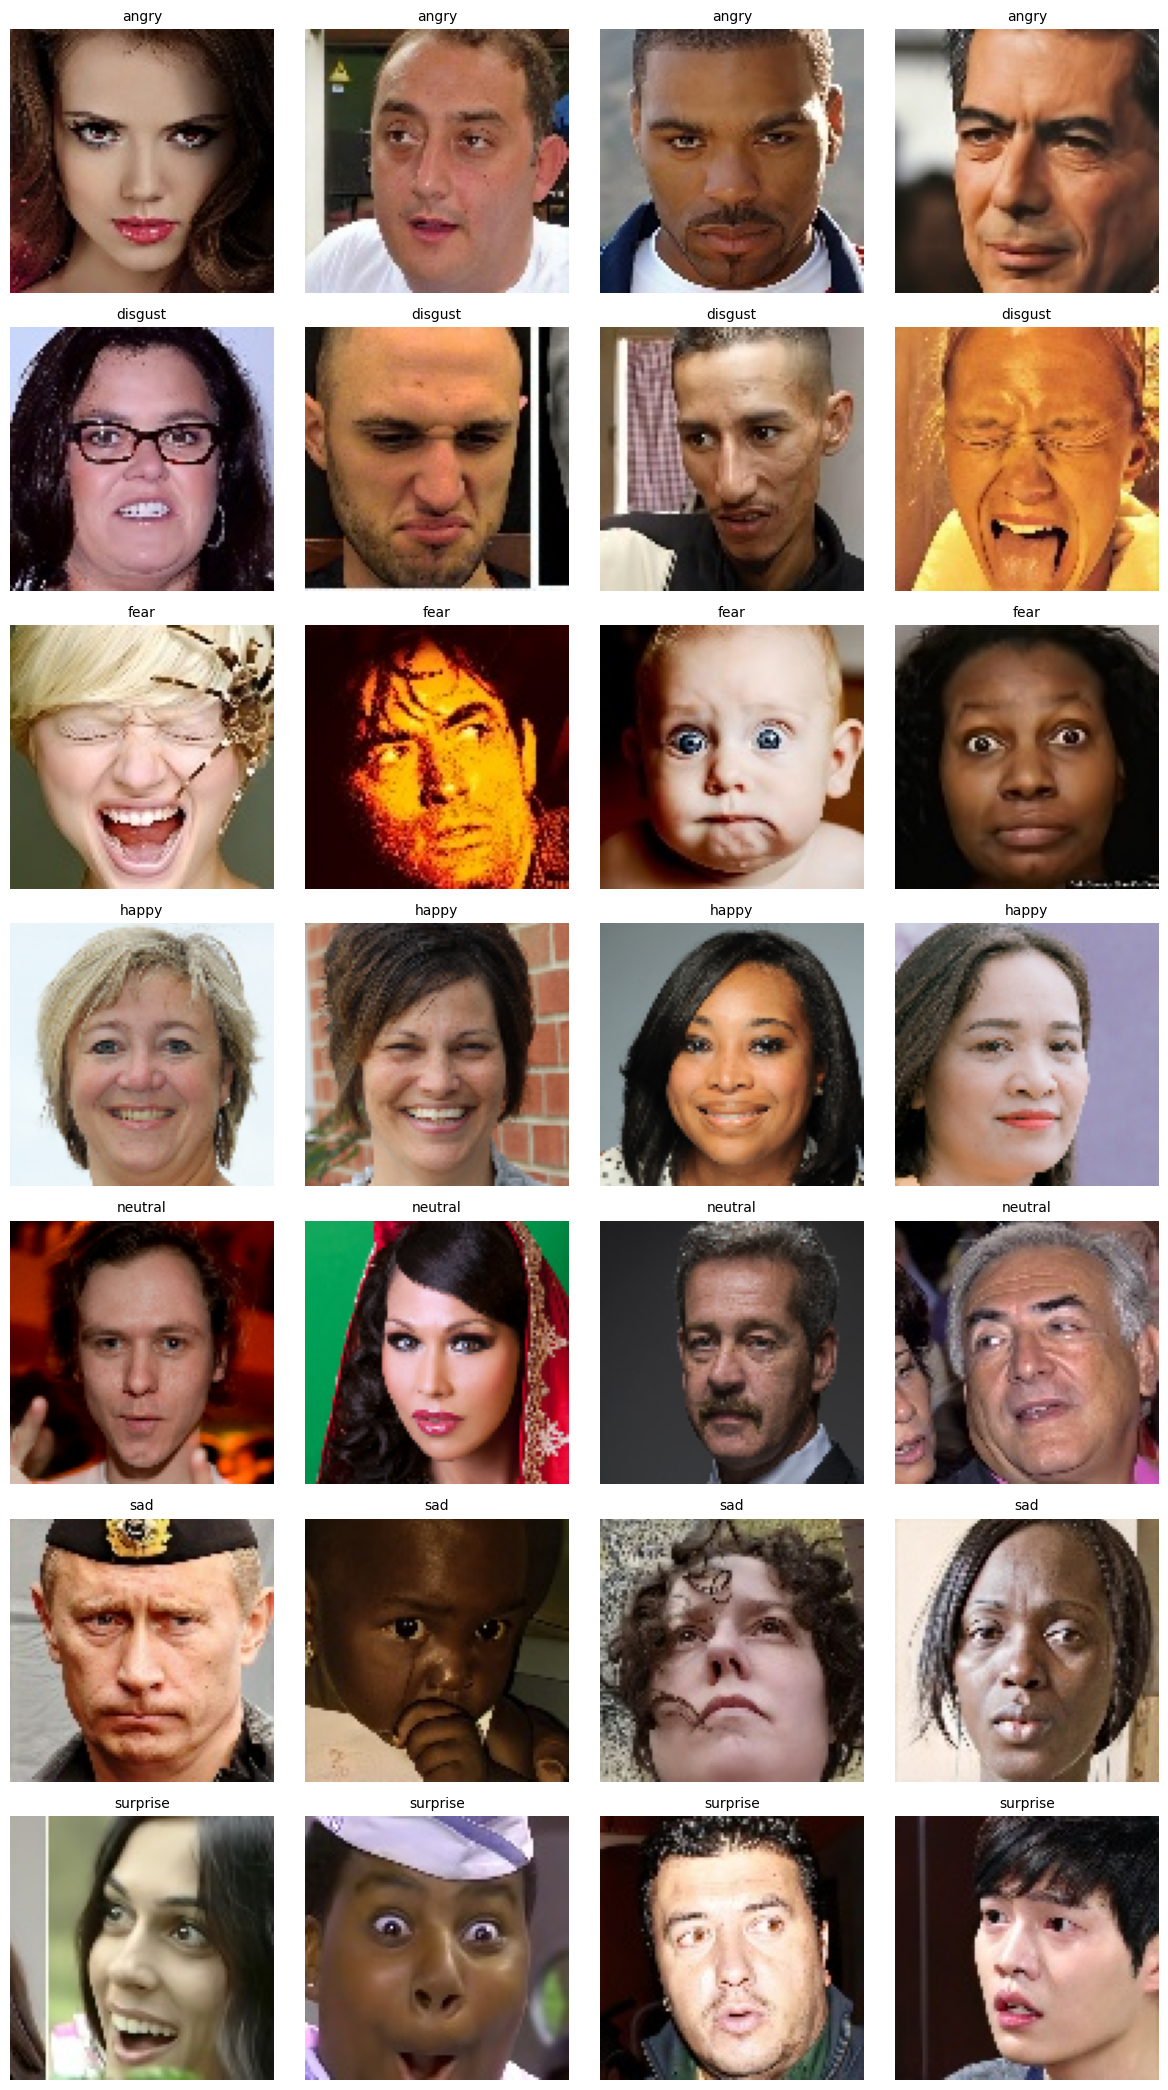

In [9]:
samples_per_class = 4
sample_df = (
    df_images.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), samples_per_class), random_state=SEED))
    .reset_index(drop=True)
)

if sample_df.empty:
    print('No sample images to display.')
else:
    labels_present = [label for label in CLASS_NAMES if label in set(sample_df['label'])]
    rows = len(labels_present)
    cols = samples_per_class
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(rows, cols)

    for row_idx, label in enumerate(labels_present):
        label_samples = sample_df[sample_df['label'] == label].reset_index(drop=True)
        for col_idx in range(cols):
            ax = axes[row_idx, col_idx]
            ax.axis('off')
            if col_idx >= len(label_samples):
                continue
            image_path = Path(label_samples.loc[col_idx, 'path'])
            try:
                image = Image.open(image_path).convert('RGB')
                ax.imshow(image)
                ax.set_title(label, fontsize=10)
            except Exception as exc:
                ax.text(0.5, 0.5, f'Cannot read\n{image_path.name}', ha='center', va='center')
                ax.set_title(label, fontsize=10)

    plt.tight_layout()
    plt.show()

## 6. Train / Validation / Test Split

19428 4163 4164


,train,valid,test
label,,,
angry,2253,482,483
disgust,1734,372,371
fear,2223,477,476
happy,3531,756,757
neutral,3588,769,769
sad,3272,701,702
surprise,2827,606,606


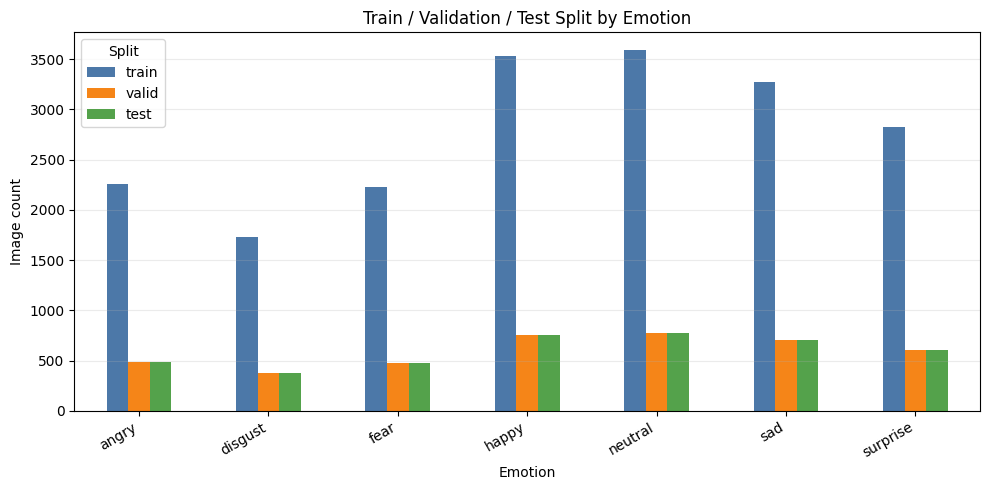

Saved split CSV files to: /data/processed


In [10]:
if df_images.empty:
    raise ValueError('No valid AffectNet data found.')

min_class_count = int(df_images['label'].value_counts().min())
if min_class_count < 2:
    raise ValueError('Each class needs at least 2 samples for stratified splitting.')

train_df, temp_df = train_test_split(
    df_images,
    test_size=VALID_SIZE + TEST_SIZE,
    stratify=df_images['label'],
    random_state=SEED,
)

relative_test = TEST_SIZE / (VALID_SIZE + TEST_SIZE)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test,
    stratify=temp_df['label'],
    random_state=SEED,
)

split_summary = pd.DataFrame({
    'train': train_df['label'].value_counts(),
    'valid': valid_df['label'].value_counts(),
    'test': test_df['label'].value_counts(),
}).reindex(CLASS_NAMES).fillna(0).astype(int)

print(len(train_df), len(valid_df), len(test_df))
display(split_summary)

fig, ax = plt.subplots(figsize=(10, 5))
split_summary.plot(kind='bar', ax=ax, color=['#4C78A8', '#F58518', '#54A24B'])
ax.set_title('Train / Validation / Test Split by Emotion')
ax.set_xlabel('Emotion')
ax.set_ylabel('Image count')
ax.legend(title='Split')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

train_df.to_csv(PROCESSED_DIR / 'train_split.csv', index=False)
valid_df.to_csv(PROCESSED_DIR / 'valid_split.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_split.csv', index=False)
print('Saved split CSV files to:', PROCESSED_DIR)

## 7. TensorFlow Datasets

Class weights: {0: 1.231881301122313, 1: 1.6005931784478498, 2: 1.2485058800848274, 3: 0.7860177205971598, 4: 0.7735308170090779, 5: 0.8482361159622773, 6: 0.9817575420688262}


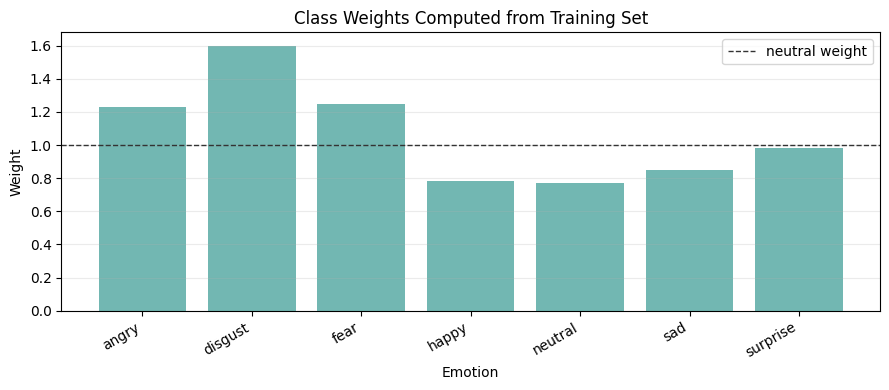

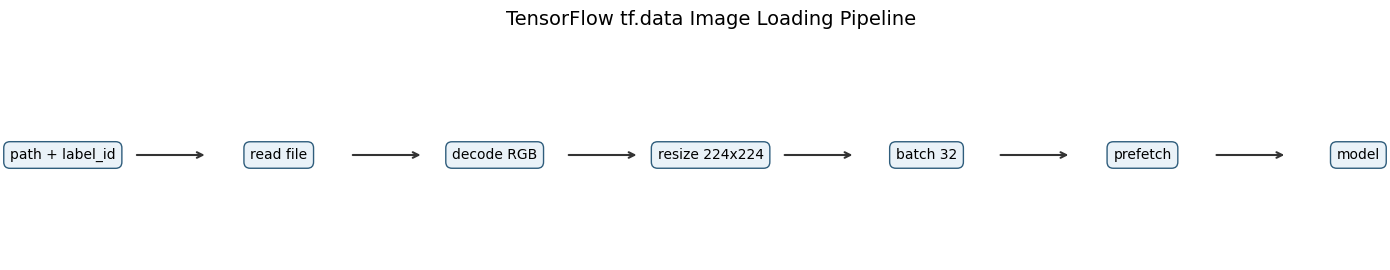

In [11]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe['path'].astype(str).values
    labels = dataframe['label_id'].astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(min(len(dataframe), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
valid_ds = make_dataset(valid_df)
test_ds = make_dataset(test_df)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_df['label_id'].values,
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_arr)}
print('Class weights:', class_weights)

class_weight_df = pd.DataFrame({
    'emotion': CLASS_NAMES,
    'class_weight': [class_weights[i] for i in range(len(CLASS_NAMES))],
})
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(class_weight_df['emotion'], class_weight_df['class_weight'], color='#72B7B2')
ax.axhline(1.0, color='#333333', linewidth=1, linestyle='--', label='neutral weight')
ax.set_title('Class Weights Computed from Training Set')
ax.set_xlabel('Emotion')
ax.set_ylabel('Weight')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

pipeline_steps = [
    'path + label_id',
    'read file',
    'decode RGB',
    'resize 224x224',
    'batch 32',
    'prefetch',
    'model',
]
fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis('off')
for i, step in enumerate(pipeline_steps):
    x = i / (len(pipeline_steps) - 1)
    ax.text(x, 0.5, step, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#EAF2F8', edgecolor='#2F5D7C'))
    if i < len(pipeline_steps) - 1:
        next_x = (i + 1) / (len(pipeline_steps) - 1)
        ax.annotate('', xy=(next_x - 0.055, 0.5), xytext=(x + 0.055, 0.5),
                    arrowprops=dict(arrowstyle='->', linewidth=1.5, color='#333333'))
ax.set_title('TensorFlow tf.data Image Loading Pipeline', fontsize=14, pad=18)
plt.tight_layout()
plt.show()

## 8. Build and Train the Model

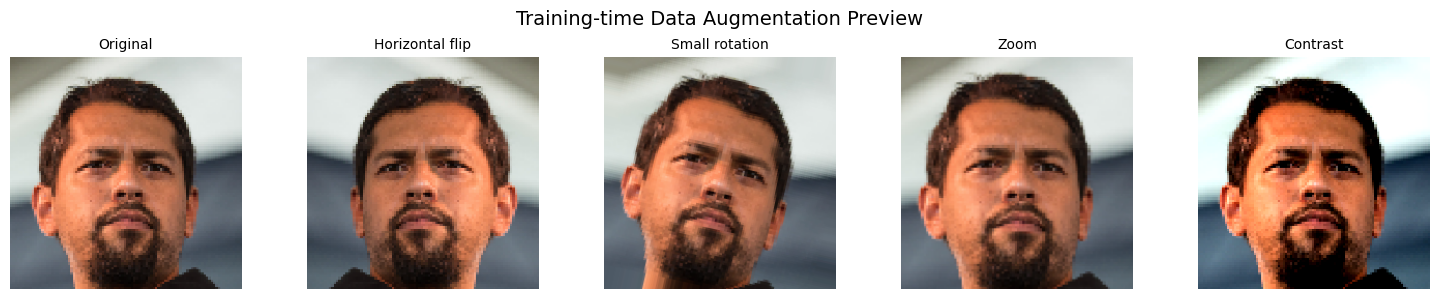

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


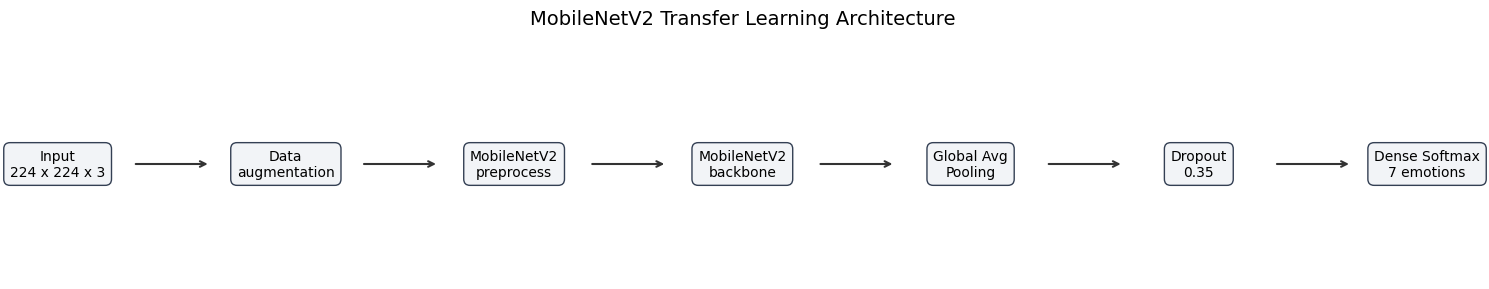

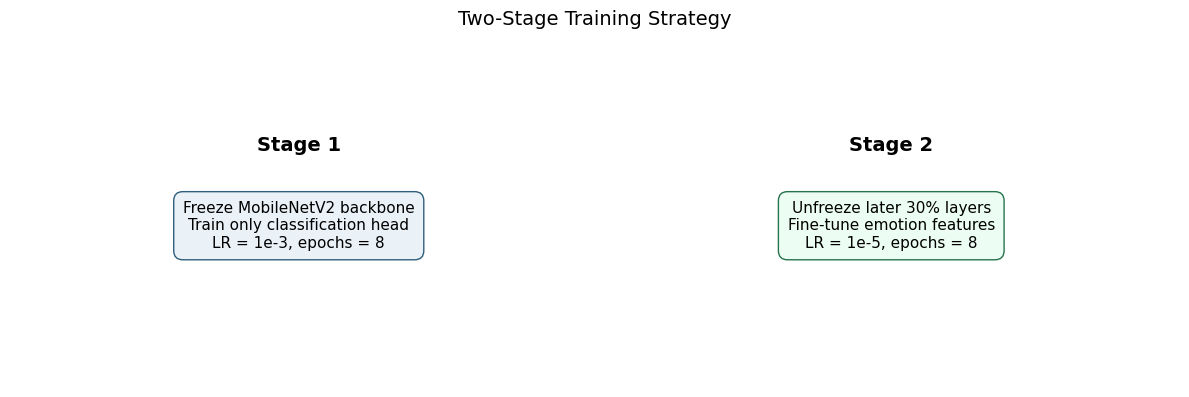

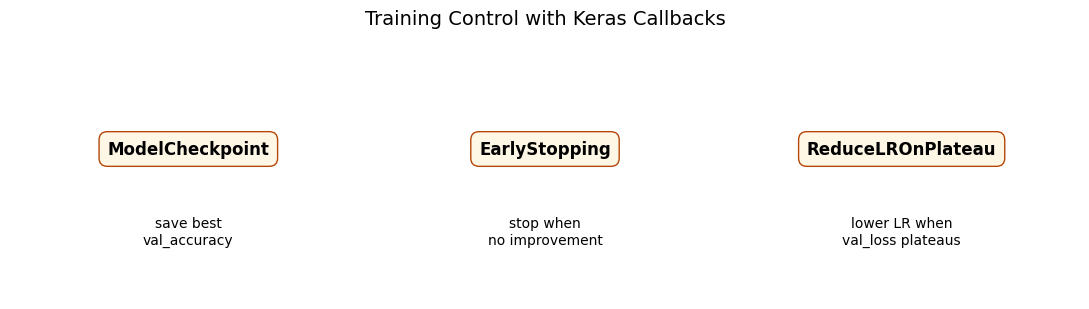

Epoch 1/8
608/608 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2712 - loss: 1.9571
Epoch 1: val_accuracy improved from None to 0.40860, saving model to /artifacts/models/best_emotion_model.keras

Epoch 1: finished saving model to /artifacts/models/best_emotion_model.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 109s 136ms/step - accuracy: 0.3207 - loss: 1.7912 - val_accuracy: 0.4086 - val_loss: 1.5152 - learning_rate: 0.0010
Epoch 2/8
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3872 - loss: 1.5881
Epoch 2: val_accuracy improved from 0.40860 to 0.44055, saving model to /artifacts/models/best_emotion_model.keras

Epoch 2: finished saving model to /artifacts/models/best_emotion_model.keras
608/608 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.3840 - loss: 1.5922 - val_accuracy: 0.4405 - val_loss: 1.4178 - learning_rate: 0.0010
Epoch 3/8
607/608 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4103 - loss: 1.5306
Epoch 3: val_accuracy improved from 0.44055 to 0.45952, saving model t

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='augmentation')

preview_row = train_df.sample(1, random_state=SEED).iloc[0]
preview_image = keras.utils.load_img(preview_row['path'], target_size=IMG_SIZE)
preview_array = keras.utils.img_to_array(preview_image)

augmentation_examples = [
    ('Original', preview_array),
    ('Horizontal flip', tf.image.flip_left_right(preview_array).numpy()),
    ('Small rotation', layers.RandomRotation(0.08, fill_mode='nearest', seed=SEED)(preview_array[None, ...], training=True)[0].numpy()),
    ('Zoom', layers.RandomZoom(0.10, fill_mode='nearest', seed=SEED)(preview_array[None, ...], training=True)[0].numpy()),
    ('Contrast', tf.image.adjust_contrast(preview_array, 1.4).numpy()),
]

fig, axes = plt.subplots(1, len(augmentation_examples), figsize=(15, 3))
for ax, (title, image) in zip(axes, augmentation_examples):
    ax.imshow(np.clip(image, 0, 255).astype('uint8'))
    ax.set_title(title, fontsize=10)
    ax.axis('off')
fig.suptitle('Training-time Data Augmentation Preview', fontsize=14)
fig.tight_layout()
plt.show()

base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax', dtype='float32')(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

checkpoint_path = MODEL_DIR / 'best_emotion_model.keras'
callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),
]

architecture_steps = [
    'Input\n224 x 224 x 3',
    'Data\naugmentation',
    'MobileNetV2\npreprocess',
    'MobileNetV2\nbackbone',
    'Global Avg\nPooling',
    'Dropout\n0.35',
    'Dense Softmax\n7 emotions',
]
fig, ax = plt.subplots(figsize=(15, 3))
ax.axis('off')
for i, step in enumerate(architecture_steps):
    x = i / (len(architecture_steps) - 1)
    ax.text(x, 0.5, step, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#F2F4F7', edgecolor='#344054'))
    if i < len(architecture_steps) - 1:
        next_x = (i + 1) / (len(architecture_steps) - 1)
        ax.annotate('', xy=(next_x - 0.055, 0.5), xytext=(x + 0.055, 0.5),
                    arrowprops=dict(arrowstyle='->', linewidth=1.5, color='#333333'))
ax.set_title('MobileNetV2 Transfer Learning Architecture', fontsize=14, pad=18)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax in axes:
    ax.axis('off')
axes[0].text(0.5, 0.72, 'Stage 1', ha='center', va='center', fontsize=14, weight='bold')
axes[0].text(0.5, 0.48, 'Freeze MobileNetV2 backbone\nTrain only classification head\nLR = 1e-3, epochs = 8',
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#EAF2F8', edgecolor='#2F5D7C'))
axes[1].text(0.5, 0.72, 'Stage 2', ha='center', va='center', fontsize=14, weight='bold')
axes[1].text(0.5, 0.48, 'Unfreeze later 30% layers\nFine-tune emotion features\nLR = 1e-5, epochs = 8',
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#ECFDF3', edgecolor='#26734D'))
fig.suptitle('Two-Stage Training Strategy', fontsize=14)
plt.tight_layout()
plt.show()

callback_steps = [
    ('ModelCheckpoint', 'save best\nval_accuracy'),
    ('EarlyStopping', 'stop when\nno improvement'),
    ('ReduceLROnPlateau', 'lower LR when\nval_loss plateaus'),
]
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
for i, (name, detail) in enumerate(callback_steps):
    x = (i + 0.5) / len(callback_steps)
    ax.text(x, 0.6, name, ha='center', va='center', fontsize=12, weight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF7E6', edgecolor='#B54708'))
    ax.text(x, 0.27, detail, ha='center', va='center', fontsize=10)
ax.set_title('Training Control with Keras Callbacks', fontsize=14, pad=18)
plt.tight_layout()
plt.show()

history_head = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    class_weight=class_weights,
)

base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.70)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks,
    class_weight=class_weights,
)

## 9. Evaluate and Save Artifacts

131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.6194 - loss: 0.9849
Test loss: 0.9849
Test accuracy: 0.6194
              precision    recall  f1-score   support

       angry       0.48      0.59      0.53       483
     disgust       0.39      0.48      0.43       371
        fear       0.47      0.48      0.48       476
       happy       0.87      0.87      0.87       757
     neutral       0.81      0.83      0.82       769
         sad       0.55      0.52      0.53       702
    surprise       0.55      0.38      0.45       606

    accuracy                           0.62      4164
   macro avg       0.59      0.59      0.59      4164
weighted avg       0.62      0.62      0.62      4164



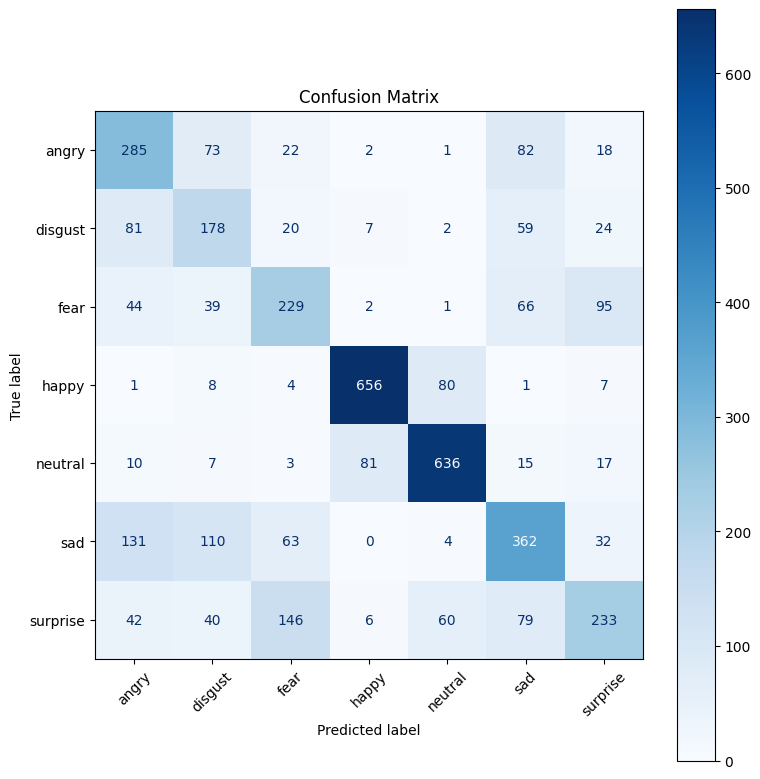

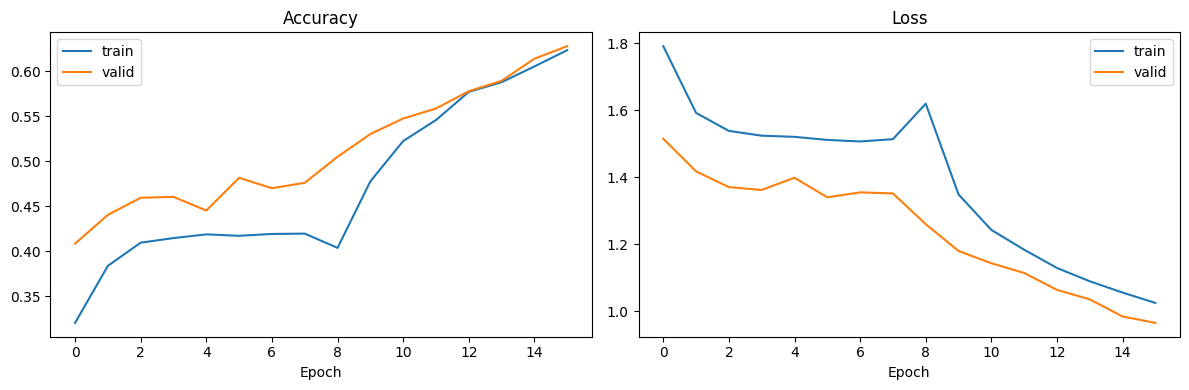

Saved model: /artifacts/models/face_emotion_mobilenetv2_v2.keras
Saved metadata: /artifacts/models/metadata_v2.json


In [13]:
def merge_history(*histories):
    merged = {}
    for hist in histories:
        for key, values in hist.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

best_model = keras.models.load_model(checkpoint_path)
test_loss, test_acc = best_model.evaluate(test_ds)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

y_true = []
y_pred = []
for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

hist = merge_history(history_head, history_fine)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist['accuracy'], label='train')
plt.plot(hist['val_accuracy'], label='valid')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['loss'], label='train')
plt.plot(hist['val_loss'], label='valid')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

final_model_path = MODEL_DIR / 'face_emotion_mobilenetv2_v2.keras'
best_model.save(final_model_path)

metadata = {
    'class_names': CLASS_NAMES,
    'img_size': IMG_SIZE,
    'kaggle_datasets': KAGGLE_DATASETS,
    'dataset_roots': [str(p) for p in dataset_roots],
    'train_samples': int(len(train_df)),
    'valid_samples': int(len(valid_df)),
    'test_samples': int(len(test_df)),
    'test_accuracy': float(test_acc),
    'class_weights': class_weights,
}

with open(MODEL_DIR / 'metadata_v2.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Saved model:', final_model_path)
print('Saved metadata:', MODEL_DIR / 'metadata_v2.json')

## 10. Single-Image Prediction and Face Detection

In [14]:
from google.colab import files
from tensorflow import keras
import json
# 123
# Upload kr
# print('keras')
# model_path = "/face_emotion_mobilenetv2_v2.keras"
# best_model = keras.models.load_model(model_path)

# # Upload metadata
# print('meta_data.json')
# metadata_file = list(files.upload().keys())[0]
# /bin
# keras
print('keras')
model_path = "/artifacts/models/best_emotion_model.keras"
best_model = keras.models.load_model(model_path)

#  metadata
# print('meta_data.json')
# metadata_file = list(files.upload().keys())[0]

print('meta_data.json')
metadata_file = "/artifacts/models/metadata_v2.json"
with open(metadata_file, "r", encoding="utf-8") as f:
    metadata = json.load(f)

CLASS_NAMES = metadata["class_names"]
IMG_SIZE = tuple(metadata["img_size"])

print("Model loaded:", model_path)
print("Metadata loaded:", metadata_file)
print("CLASS_NAMES:", CLASS_NAMES)
print("IMG_SIZE:", IMG_SIZE)

keras
meta_data.json
Model loaded: /artifacts/models/best_emotion_model.keras
Metadata loaded: /artifacts/models/metadata_v2.json
CLASS_NAMES: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
IMG_SIZE: (224, 224)


Image file: /content/bieucamcuaguongmat.jpg


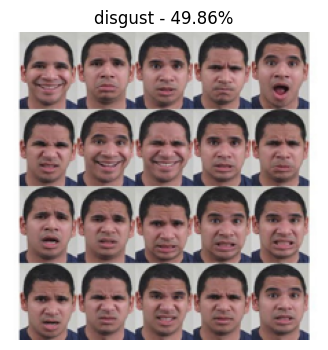

,emotion,probability
1,disgust,0.498567
2,fear,0.253155
5,sad,0.204108
6,surprise,0.034076
0,angry,0.009678
3,happy,0.000400
4,neutral,0.000015


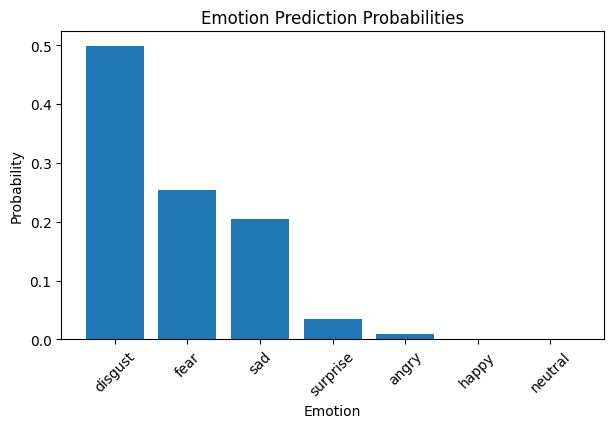

Detected faces: 20


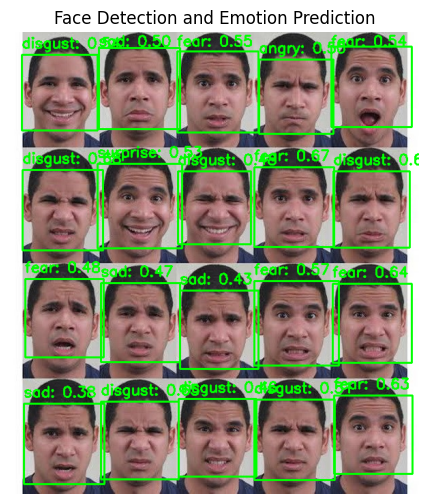

,face_id,emotion,confidence
0,1,disgust,0.541908
1,2,angry,0.503639
2,3,sad,0.500845
3,4,fear,0.554053
4,5,fear,0.535307
5,6,disgust,0.479880
6,7,disgust,0.680667
7,8,fear,0.673077
8,9,disgust,0.614573
9,10,surprise,0.528758


In [ ]:
# def predict_emotion(image_path, model=best_model):
#     image = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
#     array = np.asarray(image, dtype=np.float32)[None, ...]
#     probs = model.predict(array, verbose=0)[0]
#     pred_idx = int(np.argmax(probs))

#     plt.figure(figsize=(4, 4))
#     plt.imshow(image)
#     plt.axis('off')
#     plt.title(f'{CLASS_NAMES[pred_idx]} - {probs[pred_idx]:.2%}')
#     plt.show()

#     return pd.DataFrame({'emotion': CLASS_NAMES, 'probability': probs}).sort_values('probability', ascending=False)


# face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


# def detect_faces_and_predict(image_path, model=best_model):
#     bgr = cv2.imread(str(image_path))
#     if bgr is None:
#         raise FileNotFoundError(image_path)

#     gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
#     faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))

#     for (x, y, w, h) in faces:
#         face = bgr[y:y+h, x:x+w]
#         face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
#         face_rgb = cv2.resize(face_rgb, IMG_SIZE)
#         probs = model.predict(face_rgb[None, ...].astype(np.float32), verbose=0)[0]
#         pred = CLASS_NAMES[int(np.argmax(probs))]
#         conf = float(np.max(probs))

#         cv2.rectangle(bgr, (x, y), (x+w, y+h), (0, 255, 0), 2)
#         cv2.putText(bgr, f'{pred}: {conf:.2f}', (x, max(y-10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

#     rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
#     plt.figure(figsize=(8, 6))
#     plt.imshow(rgb)
#     plt.axis('off')
#     plt.show()

#     return faces



from google.colab import files
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# uploaded_image = files.upload()

# image_path = list(uploaded_image.keys())[0]
# multifaces and emotions
image_path = "/content/bieucamcuaguongmat.jpg"
#single 
image_path1 = ''
print("Image file:", image_path)


def predict_emotion(image_path1, model=best_model):
    image = Image.open(image_path1).convert("RGB").resize(IMG_SIZE)
    array = np.asarray(image, dtype=np.float32)[None, ...]

    probs = model.predict(array, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{pred_label} - {confidence:.2%}")
    plt.show()

    result_df = pd.DataFrame({
        "emotion": CLASS_NAMES,
        "probability": probs
    }).sort_values("probability", ascending=False)

    display(result_df)

    plt.figure(figsize=(7, 4))
    plt.bar(result_df["emotion"], result_df["probability"])
    plt.xlabel("Emotion")
    plt.ylabel("Probability")
    plt.title("Emotion Prediction Probabilities")
    plt.xticks(rotation=45)
    plt.show()

    return result_df



#haar cascade classifieer
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


def detect_faces_and_predict(image_path, model=best_model):
    bgr = cv2.imread(str(image_path))

    if bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40)
    )

    print(f"Detected faces: {len(faces)}")

    results = []

    for i, (x, y, w, h) in enumerate(faces, start=1):
        face = bgr[y:y+h, x:x+w]
        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face_rgb = cv2.resize(face_rgb, IMG_SIZE)

        probs = model.predict(face_rgb[None, ...].astype(np.float32), verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        pred_label = CLASS_NAMES[pred_idx]
        confidence = float(np.max(probs))

        results.append({
            "face_id": i,
            "emotion": pred_label,
            "confidence": confidence
        })

        cv2.rectangle(
            bgr,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            bgr,
            f"{pred_label}: {confidence:.2f}",
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title("Face Detection and Emotion Prediction")
    plt.show()

    if len(results) > 0:
        results_df = pd.DataFrame(results)
        display(results_df)
        return results_df
    else:
        print("No face detected. Full-image prediction is shown below.")
        return pd.DataFrame(columns=["face_id", "emotion", "confidence"])


# Run prediction on full uploaded image
single_result = predict_emotion(image_path, model=best_model)

# Run face detection and prediction
face_result = detect_faces_and_predict(image_path, model=best_model)
